#### Imports

In [1]:
# local imports
from dist_gen import *

# external imports
import matplotlib.animation as anim
import matplotlib.pyplot as plt
from collections import namedtuple
import numpy as np
#import pandas as pd
#import plasmapy as plas
#import random as rd

#### 1D Particle Simulation

Particle Definition and Data Handling

Parameters

In [24]:
N_e = 500 # number of electrons
N_i = 500 # number of ions
x_min, x_max = -10, 10
v_min, v_max = -10, 10
dt = 0.01
e = 1.602e-19
k = 1e4 #8.987e9

def E(x) -> float: # electric field
    return 0

def x_dist(x) -> float:
    return 1

def v_dist(v) -> float:
    return np.e**-((10*((v/v_max)-0.6))**2) + np.e**-((10*((v/v_max)+0.6))**2)

In [25]:
electron: dict = {
    "name": "Electron",
    "charge": -1*e,
    "mass": 9.109e-31
}

ion: dict = {
    "name": "Ion",
    "charge": e,
    "mass": 1.673e-27
}

# particle data
name_list: list = []
pos_list:  list = []
vel_list:  list = []
acc_list:  list = []
chg_list:  list = []
mass_list: list = []

lists: list = [name_list, pos_list, vel_list, acc_list, chg_list, mass_list]

def add_particles(particle: dict, n: int) -> None:
    for i in range(n):
        name_list.append(particle["name"])
        pos_list.append(rand_from_dist(x_dist, x_min, x_max, 100/x_max, True))
        vel_list.append(rand_from_dist(v_dist, v_min, v_max, 100/v_max, True))
        acc_list.append(0)
        chg_list.append(particle["charge"])
        mass_list.append(particle["mass"])

Simulation Functions

In [26]:
def init():
    global lists
    for i in range(len(lists)):
        lists[i].clear()
    add_particles(electron, N_e)
    add_particles(ion, N_i)

def coulomb_force(j, i): # coulomb force by particle j on particle i
    L = x_max - x_min
    r_qp = pos_list[i] - pos_list[j]
    r_qp -= L * np.round(r_qp / L)
    dir = r_qp / np.abs(r_qp)
    return k * ((chg_list[i]*chg_list[j])/(r_qp**2))*dir

def step(frame):
    global ax
    N = len(name_list)
    for i in range(N):
        pos_list[i] += vel_list[i] * dt + 0.5 * acc_list[i] * dt**2
        if pos_list[i] < x_min:
            pos_list[i] += x_max - x_min
        elif pos_list[i] > x_max:
            pos_list[i] -= x_max - x_min
    for i in range(N):
        acc_list[i] = 0
        for j in range(i+1, N):
            f = coulomb_force(i,j)
            acc_list[i] += f / mass_list[i]
            acc_list[j] -= f / mass_list[j]
    for i in range(N):
        vel_list[i] += acc_list[i] * dt
    ax.set_title("t = " + str(float(f'{frame*dt:.9f}')))
    print("Current frame: " + str(frame), end='\r')
    view = plt.hist2d(pos_list, vel_list, bins=100, range=[[x_min, x_max], [v_min, v_max]], cmap='hot')
    return view

Creating an Animation

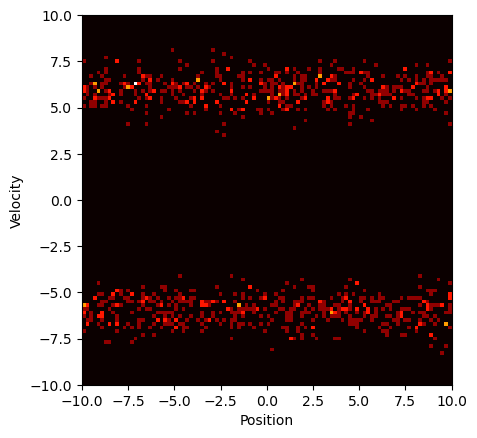

In [27]:
init()

fig, ax = plt.subplots()
plt.hist2d(pos_list, vel_list, bins=100, range=[[x_min, x_max], [v_min, v_max]], cmap='hot')
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_box_aspect(1)

MovieWriter ffmpeg unavailable; using Pillow instead.


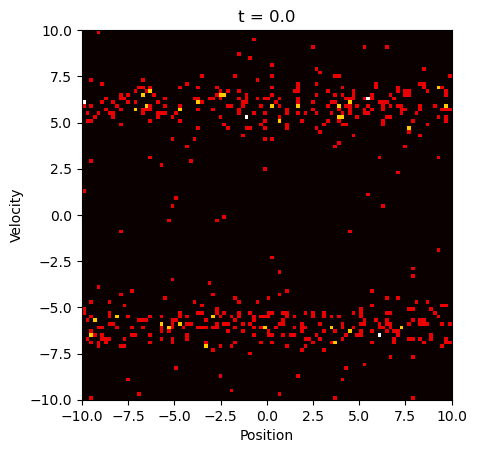

In [28]:
fig, ax = plt.subplots()
view = plt.hist2d(pos_list, vel_list, bins=100, range=[[x_min, x_max], [v_min, v_max]], cmap='hot')
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_box_aspect(1)

ani = anim.FuncAnimation(fig=fig, func=step, frames=60, interval=30)
ani.save("first_sim.gif")

In [7]:
a = [1, 2, 3]
b = [4, 5, 6]
c = [7, 8, 9]

test_list = [a, b, c]

a.append("foo")
test_list[0]

[1, 2, 3, 'foo']

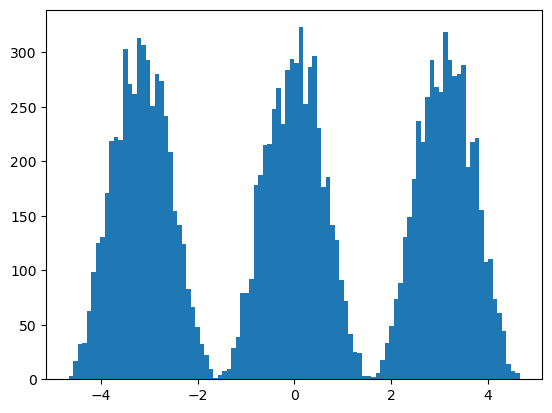

In [8]:
def test_func(x) -> float:
    return np.cos(x)**2

plt.hist(rfd_array(test_func, 15000, [-3*np.pi/2, 3*np.pi/2]), 100);